In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Go up one level from doomsday/ to habitability/
sys.path.insert(0, str(Path.cwd().parent))
from calculator import SeaIceCalc, Habitability, SST, SRD, Tempdiff, Tempdiffall
from timeseries_calc import OceanParam, WholeGlobeParam, LandParam, SeaIce

In [3]:
file = "../../solarflux/stability/run_1.25_5yr/output_daily.nc"
ds = xr.open_dataset(file)
ds_crop = ds.sel(time=slice("2003-01-01", "2003-12-31"))
times = ds_crop.time.dt.dayofyear.values

In [4]:
# Compare with Earth

months_to_keep = [3,6,9,12]

file_earth = "../../earth/output.nc"
earth_data = xr.open_dataset(file_earth)
earth_crop = earth_data.sel(time=slice("2003-01-01", "2003-12-31"))

file_snow = "../../solarflux/stability/run_0.1_5yr/output.nc"
ds_snow = xr.open_dataset(file_snow)
snow_crop = ds_snow.sel(time=slice("2003-01-01", "2003-12-31"))

# Functions that return a scalar for a given monthly dataset
def layer_temp_mean(ds, layer_idx):
    return WholeGlobeParam.globalparam_timeseries(ds["temp"].isel(layer=layer_idx)).mean()

def tsurf_mean(ds):
    return WholeGlobeParam.globalparam_timeseries(ds["tsurf"]).mean()

def st_mean(ds, soil_layer_idx):
    # keep same lsm choice you used previously
    lsm_mask = ds["lsm"]
    return LandParam.landparam_timeseries(ds["st"].isel(soil_layer=soil_layer_idx), lsm=lsm_mask).mean()

# The ordered list of "layers" we plot (0..7 temp layers, then tsurf, st0, st1)
sigma_vals = [0.0625, 0.1875, 0.3125, 0.4375, 0.5625, 0.6875, 0.8125, 0.9375, 1]
layer_labels = [f"{s:.4f}$\\sigma$" for s in sigma_vals] + ["Soil Layer 0", "Soil Layer 1"]
n_layers = len(layer_labels)

# compute a DataFrame: rows = months, columns = layers
results = pd.DataFrame(index=months_to_keep, columns=layer_labels, dtype=float)

# Earth vals
vals_earth = []
for i in range(8):
        vals_earth.append(layer_temp_mean(earth_crop, i))
vals_earth.append(tsurf_mean(earth_crop))
vals_earth.append(st_mean(earth_crop, 0))
vals_earth.append(st_mean(earth_crop, 1))

# New planet vals
vals_hot = []
for i in range(8):
        vals_hot.append(layer_temp_mean(ds_crop, i))
vals_hot.append(tsurf_mean(ds_crop))
vals_hot.append(st_mean(ds_crop, 0))
vals_hot.append(st_mean(ds_crop, 1))

# Snowball vals
vals_snow = []
for i in range(8):
        vals_snow.append(layer_temp_mean(snow_crop, i))
vals_snow.append(tsurf_mean(snow_crop))
vals_snow.append(st_mean(snow_crop, 0))
vals_snow.append(st_mean(snow_crop, 1))

In [5]:
# Compare humidity with Earth
def layer_humid_mean(ds, layer_idx):
    return WholeGlobeParam.globalparam_timeseries(ds["humid"].isel(layer=layer_idx)).mean()

# The ordered list of "layers" we plot (0..7 temp layers, then tsurf, st0, st1)
sigma_vals_humid = [0.0625, 0.1875, 0.3125, 0.4375, 0.5625, 0.6875, 0.8125, 0.9375]
layer_labels_humid = [f"{s:.4f}$\\sigma$" for s in sigma_vals_humid]
n_layers_humid = len(layer_labels_humid)

# compute a DataFrame: rows = months, columns = layers
results_humid = pd.DataFrame(index=months_to_keep, columns=layer_labels_humid, dtype=float)

# Earth vals
vals_earth_humid = []
vals_hot_humid = []
vals_snow_humid = []
for i in range(8):
        vals_earth_humid.append(layer_humid_mean(earth_crop, i))
        vals_hot_humid.append(layer_humid_mean(ds_crop, i))
        vals_snow_humid.append(layer_humid_mean(snow_crop, i))


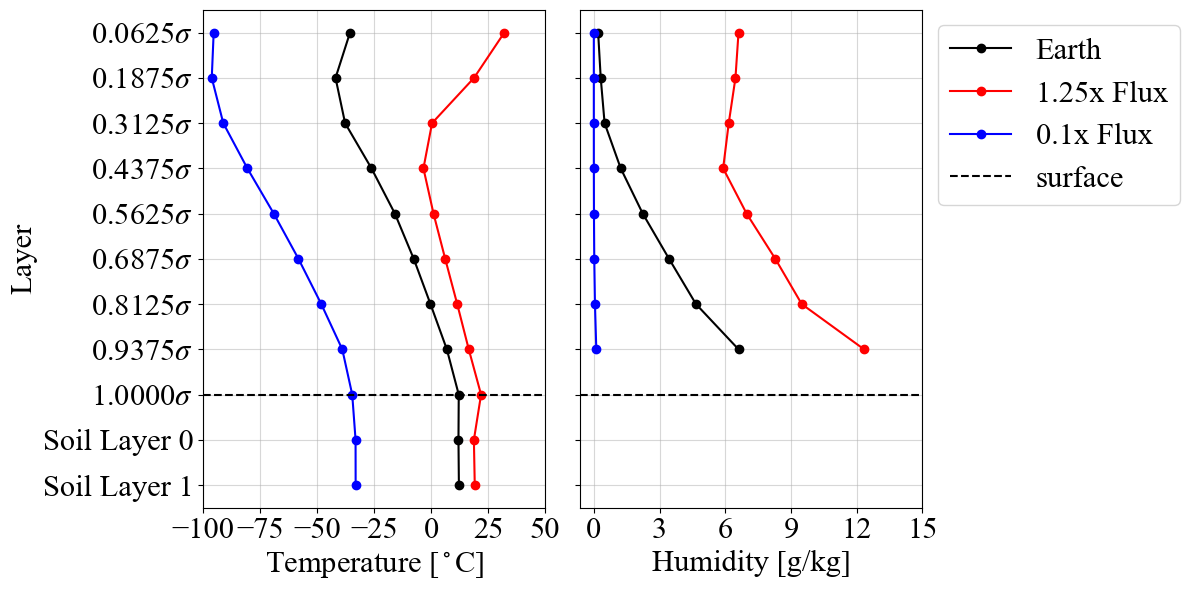

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Global Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'

fig, (ax1, ax2) = plt.subplots(
    ncols=2, 
    figsize=(12, 6), 
    sharey=True
)

y_pos = list(range(n_layers))

ax1.plot(vals_earth, y_pos, marker='o', label="Earth", color="black")
ax1.plot(vals_hot, y_pos, marker='o', label="1.25x Flux", color="red")
ax1.plot(vals_snow, y_pos, marker='o', label="0.1x Flux", color="blue")

ax1.set_xlabel("Temperature [$^\\circ$C]", size=22)
ax1.set_ylabel("Layer", size=22)
ax1.set_yticks(y_pos)
ax1.set_xlim(-100,50)
ax1.set_yticklabels(layer_labels, size=22)
ax1.set_xticks([-100,-75, -50, -25, 0, 25,50])
ax1.tick_params(axis='x', labelsize=22)
ax1.invert_yaxis()
ax1.grid(True, alpha=0.5)
ax1.axhline(y_pos[8], linestyle="--", color="black", label="surface")

y_pos_h = list(range(n_layers_humid))
vals_earth_humid2 = np.array(vals_earth_humid) * 1000
vals_hot_humid2 = np.array(vals_hot_humid) * 1000
vals_snow_humid2 = np.array(vals_snow_humid) * 1000
ax2.plot(vals_earth_humid2, y_pos_h, marker='o', label="Earth", color="black")
ax2.plot(vals_hot_humid2, y_pos_h, marker='o', label="1.25x Flux", color="red")
ax2.plot(vals_snow_humid2, y_pos_h, marker='o', label="0.1x Flux", color="blue")

ax2.set_xlabel("Humidity [g/kg]", size=22)
# ax2.set_xticks([0, 0.01])
ax2.tick_params(axis='x', labelsize=22)
ax2.set_xticks([0,3,6,9,12,15])
ax2.grid(True, alpha=0.5)
ax2.axhline(8, linestyle="--", color="black", label="surface")

ax2.legend(fontsize=22, bbox_to_anchor=(1, 1))
plt.tight_layout()
# plt.savefig("1.25flux_temphumid.png", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/_z/12jwk5k94hvctprv3dvrm2_c0000gp/T/ipykernel_32696/3156962190.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


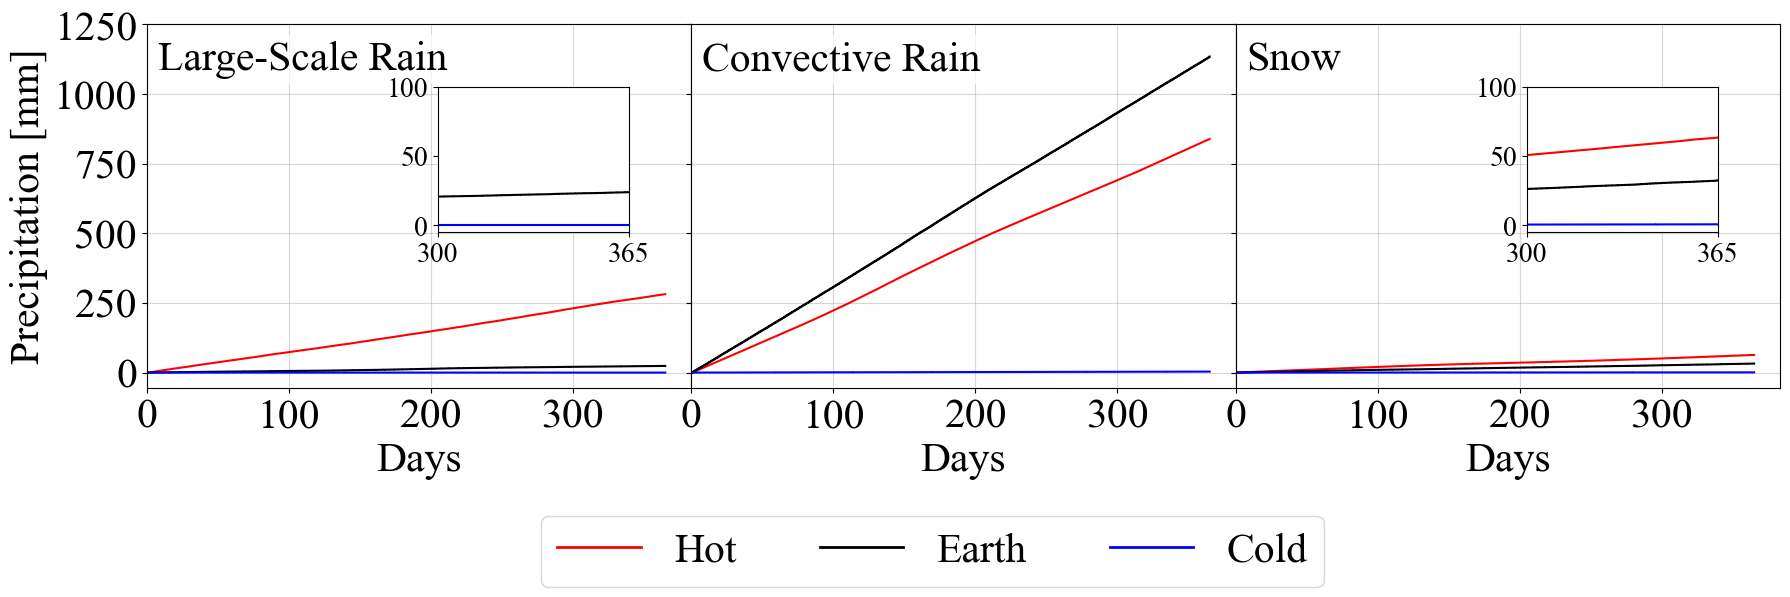

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Define variable names and labels for each precipitation type
precip_vars = [
    ("rain_cond", "Large-Scale Rain"),
    ("rain_conv", "Convective Rain"),
    ("snow_cond", "Snow"),
]

colors = {
    "Hot": "red",
    "Earth": "black",
    "Cold": "blue",
}

times_earth = earth_crop.time.dt.dayofyear.values
times_cold = snow_crop.time.dt.dayofyear.values

datasets = [
    (ds_crop, times, "Hot"),
    (earth_crop, times_earth, "Earth"),
    (snow_crop, times_cold, "Cold"),
]

# Calculate accumulated precipitation arrays
precip_data = []
for var, label in precip_vars:
    series = []
    for ds, _, _ in datasets:
        arr = WholeGlobeParam.globalparam_timeseries(ds[var])
        series.append(arr)
    precip_data.append((series, label))

# Plot with no gaps between panels
fig, axes = plt.subplots(
    ncols=3,
    figsize=(18, 5),
    sharex=True,
    sharey=True,
    gridspec_kw={"wspace": 0}
)

for i, (ax, (series, title)) in enumerate(zip(axes, precip_data)):

    if i != 1:
        axins = inset_axes(ax, width="35%", height="40%", loc="upper right", borderpad=4.5)

    for arr, (ds, t, name) in zip(series, datasets):
        ax.plot(t, arr - arr[0], color=colors[name])

        if i != 1:
            axins.plot(t, arr - arr[0], color=colors[name])
            axins.set_xlim(300,365)
            axins.tick_params(axis="both",labelsize=20)
            axins.set_yticks([0,50,100])
            axins.set_xticks([300,365])
            axins.set_ylim(-5, 100)

    ax.text(0.02, 0.85, title,
            transform=ax.transAxes,
            ha="left", va="bottom",
            size=30,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )


    # only left plot gets the y-label
    if i == 0:
        ax.set_ylabel("Precipitation [mm]", size=30)
    else:
        ax.tick_params(labelleft=False)

    

    ax.set_xlabel("Days", size=30)
    ax.set_xlim(left=0)
    ax.set_xticks([0,100,200,300])
    ax.set_yticks([0,250,500,750,1000,1250])
    ax.tick_params(axis="x", labelsize=30)
    ax.tick_params(axis="y", labelsize=30)
    ax.grid(True, alpha=0.5)

# One legend for Hot / Earth / Cold only
legend_handles = [
    Line2D([0], [0], color=colors[name], lw=2, label=name)
    for name in ["Hot", "Earth", "Cold"]
]
fig.legend(handles=legend_handles, fontsize=30, ncol=3, bbox_to_anchor=(0.75,0))

plt.tight_layout()
# plt.savefig("precipitation.png", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
ds_05 = xr.open_dataset("../../solarflux/0.5.nc")
ds_025 = xr.open_dataset("../../solarflux/0.25.nc")

ds_025_crop = ds_025.sel(time=slice("2001-01-01", "2002-01-01"))
ds_05_crop = ds_05.sel(time=slice("2001-01-01", "2002-01-01"))